# Notebook 03b — AH-PC k=1 Sanity Check (Single-Horizon Pre-Training)

This notebook is a **controlled ablation** of Notebook 03. It strips AH-PC down to a
single prediction horizon (k=1 second only) to sanity-check the raw-feature-space
decoding scheme in isolation, before judging whether the multi-horizon Horizon
Attention Module adds value on top of it.

## Why a k=1-only variant?

Notebook 03's full model predicts 4 horizons (k=1,2,4,8) with a learned soft-routing
Horizon Attention Module deciding how much each horizon contributes to the loss. If
something in the fine-tuned classification accuracy looks off, it's hard to tell
whether the cause is the raw-feature-space decoding itself or the multi-horizon
attention mechanism. This notebook removes that second variable entirely:

- **Only k=1** is predicted — the single next-second segment.
- **No Horizon Attention Module** — with one horizon there is nothing to route between,
  so alpha is trivially 1.0 and is dropped from the model and loss entirely.
- **Loss is a plain MSE** between the single decoder's prediction and the actual
  segment at t+1 — no per-horizon weighting term.

Everything else — encoder, decoder architecture, optimizer, schedule, checkpointing —
is identical to Notebook 03, so any accuracy difference downstream can be attributed to
the multi-horizon mechanism rather than to some other confound.

## Smoke test

`SMOKE_TEST = True` (default below) runs only 2 epochs to verify the notebook executes
cleanly. Once confirmed, set it to `False` and re-run for full 100-epoch training.

---
## Setup and Imports

In [2]:
import os
import math
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:   {device}")

PyTorch 2.12.1+cu130
CUDA available: False
Using device:   cpu


---
## 1. Model Definition

Identical encoder and decoder architecture to Notebook 03, but with only **one**
horizon (k=1) and **no Horizon Attention Module** — there is nothing to route between
with a single decoder head, so alpha is dropped entirely rather than hard-coded to 1.0.

Architecture recap:
- **Sheibani Encoder** (untouched, identical to Notebook 03): BandAttention + ChannelAttention + CNN + Bottleneck → (B, 64, 15, 5)
- **Single Decoder Head** (ConvTranspose2d, k=1 only, identical block to Notebook 03's per-horizon decoder): bottleneck (B,64,15,5) → ConvTranspose2d(64→32,k=(2,1),s=(2,1)) → ReLU → ConvTranspose2d(32→16,k=(2,1),s=(2,1)) → ReLU → Conv2d(16→1,k=3) → Upsample(62,5) → prediction (B, 62, 5)
- **Projector** (fine-tuning use only, via `get_embedding()` — **not** part of the pre-training loss): Flatten(4800) → Linear(4800→256) + LayerNorm → z_t (B, 256)

In [3]:
# ── Sheibani's attention modules (reproduced exactly, identical to Notebook 03) ─────

class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)


class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)


# ── Sheibani's CNN encoder + bottleneck (reproduced exactly) ───────────────

class SheibaniEncoder(nn.Module):
    """
    Attention-gated CNN encoder. Returns (B, 64, 15, 5) feature map.
    """
    OUT_CHANNELS = 64

    def __init__(self):
        super().__init__()
        self.band_attn    = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

    def forward(self, x):  # x: (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x  # (B, 64, 15, 5)


# ── AH-PC k=1 sanity components ─────────────────────────────────────────────

HORIZONS        = [1]           # k=1 only — no multi-horizon routing
LATENT_DIM      = 256           # only used by get_embedding's projector (fine-tuning)
BOTTLENECK_FLAT = 64 * 15 * 5   # 4800 — flattened (C, H, W) bottleneck


class HorizonDecoder(nn.Module):
    """Single k=1 decoder: bottleneck -> predicted raw segment at t+1, (B, 62, 5).
    Identical ConvTranspose2d block to Notebook 03's per-horizon decoder."""
    def __init__(self):
        super().__init__()
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=(2, 1), stride=(2, 1)),  # (B,32,30,5)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=(2, 1), stride=(2, 1)),  # (B,16,60,5)
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),                    # (B,1,60,5)
        )
        self.upsample = nn.Upsample(size=(62, 5), mode="bilinear", align_corners=False)

    def forward(self, bottleneck):  # bottleneck: (B, 64, 15, 5)
        x = self.deconv(bottleneck)
        x = self.upsample(x)        # (B, 1, 62, 5)
        return x.squeeze(1)         # (B, 62, 5)


# ── Full AH-PC k=1 model ─────────────────────────────────────────────────────

class AHPCModel(nn.Module):
    """Same encoder/decoder/projector as Notebook 03, but no Horizon Attention Module —
    with a single horizon there is nothing to route between."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.sheibani_encoder = SheibaniEncoder()
        self.decoder = HorizonDecoder()
        # Projector is used only by get_embedding() for fine-tuning — it plays no part
        # in the pre-training loss, which is computed directly in raw feature space.
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(BOTTLENECK_FLAT, latent_dim),
            nn.LayerNorm(latent_dim),
        )

    def get_embedding(self, x):  # x: (B, 62, 5) -> (B, 256). Fine-tuning use only.
        bottleneck = self.sheibani_encoder(x)
        return self.projector(bottleneck)

    def forward(self, anchor):   # anchor: (B, 62, 5)
        bottleneck = self.sheibani_encoder(anchor)  # (B, 64, 15, 5)
        pred       = self.decoder(bottleneck)        # (B, 62, 5)
        return bottleneck, pred


# Quick sanity check
_m = AHPCModel()
_x = torch.randn(4, 62, 5)
with torch.no_grad():
    _bn, _p = _m(_x)
    _emb = _m.get_embedding(_x)
print(f"Model OK  |  bottleneck: {_bn.shape}  pred[k=1]: {_p.shape}")
print(f"get_embedding (fine-tuning only): {_emb.shape}")
print(f"Total params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _x, _bn, _p, _emb

Model OK  |  bottleneck: torch.Size([4, 64, 15, 5])  pred[k=1]: torch.Size([4, 62, 5])
get_embedding (fine-tuning only): torch.Size([4, 256])
Total params: 1,264,297


---
## 2. Dataset and Train/Val Split

Same processed data and same subject-level split as Notebook 03. Only the k=1 target is
loaded per pair — k=2/4/8 targets exist in the pkl files but are irrelevant here.

- `anchor`: (62, 5) — current 1-second EEG segment
- `t1`: (62, 5) — the actual segment at t+1 second
- `label`: emotion class (0–4), carried along but **not used during pre-training**

### Why split by subject, not randomly?

Consecutive segments in the same trial are highly correlated. Splitting at the
**subject level** ensures the model has never seen *any* data from val subjects, giving
an honest estimate of generalisation — identical rationale to Notebook 03.

In [4]:
DATA_DIR = "/workspaces/AH-PC/src/data/processed"

TRAIN_SUBJECTS = list(range(1, 14))   # subjects 1–13  → 19,019 pairs
VAL_SUBJECTS   = list(range(14, 17))  # subjects 14–16 →  4,389 pairs


class SingleHorizonEEGDataset(Dataset):
    """
    Loads k=1-only EEG pairs for a given list of subject IDs.
    Returns: (anchor, t1, label) — all tensors.
    Labels are not used during pre-training but are included for
    compatibility with the fine-tuning stage.
    """

    def __init__(self, subject_ids, data_dir=DATA_DIR):
        self.samples = []
        for sid in sorted(subject_ids):
            path = os.path.join(data_dir, f"subject_{sid:02d}_pairs.pkl")
            with open(path, "rb") as f:
                pairs = pickle.load(f)
            self.samples.extend(pairs)
        print(f"  Loaded {len(self.samples):,} pairs "
              f"from subjects {sorted(subject_ids)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p      = self.samples[idx]
        anchor = torch.tensor(p["anchor"],     dtype=torch.float32)  # (62, 5)
        t1     = torch.tensor(p["targets"][1], dtype=torch.float32)  # (62, 5)
        label  = torch.tensor(p["label"],      dtype=torch.long)
        return anchor, t1, label

In [5]:
BATCH_SIZE = 64

print("Building datasets...")
train_dataset = SingleHorizonEEGDataset(TRAIN_SUBJECTS)
val_dataset   = SingleHorizonEEGDataset(VAL_SUBJECTS)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset):,} pairs  →  {len(train_loader)} batches")
print(f"  Val:   {len(val_dataset):,} pairs  →  {len(val_loader)} batches")

# Verify a batch
_a, _t1, _lbl = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  anchor: {_a.shape}   t1: {_t1.shape}   label: {_lbl.shape}")
del _a, _t1, _lbl

Building datasets...
  Loaded 19,019 pairs from subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
  Loaded 4,389 pairs from subjects [14, 15, 16]

Dataset sizes:
  Train: 19,019 pairs  →  298 batches
  Val:   4,389 pairs  →  69 batches

Batch shapes:
  anchor: torch.Size([64, 62, 5])   t1: torch.Size([64, 62, 5])   label: torch.Size([64])


---
## 3. k=1 Reconstruction Loss

With a single horizon there is no routing weight to learn, so the loss is a plain MSE
between the decoder's predicted next-second segment and the actual one:

$$\mathcal{L} = \frac{1}{B} \sum_{b=1}^{B} \text{MSE}\bigl(\hat{x}_{b,t+1},\; x_{b,t+1}\bigr)$$

No stop-gradient, no target encoder, no alpha weighting — same simplification rationale
as Notebook 03's raw-feature-space loss, minus the multi-horizon weighting term.

In [6]:
def compute_loss(model, anchor, target, device):
    """
    k=1 reconstruction loss: MSE(decoder(bottleneck_t), actual_segment[i+1]).

    Args:
        model:  AHPCModel in train or eval mode
        anchor: (B, 62, 5) on device
        target: (B, 62, 5) on device — the actual segment at t+1

    Returns:
        loss: scalar tensor (call .backward() during training; also usable directly for logging)
    """
    _, pred = model(anchor)
    loss = F.mse_loss(pred, target)
    return loss


# Smoke-test the loss function on one batch
_model_tmp = AHPCModel().to(device)
_a, _t1, _ = next(iter(train_loader))
_anchor = _a.to(device)
_target = _t1.to(device)
_loss = compute_loss(_model_tmp, _anchor, _target, device)
print(f"Loss function OK")
print(f"  loss: {_loss.item():.5f}")
del _model_tmp, _a, _t1, _anchor, _target, _loss

Loss function OK
  loss: 44.63629


---
## 4. Training Configuration

Identical optimizer, LR schedule, and early-stopping setup to Notebook 03 — only the
checkpoint path changes so the k=1 sanity model doesn't overwrite the full 4-horizon
checkpoint.

### Optimizer: AdamW, lr=1e-3, weight_decay=1e-4

### LR schedule: linear warmup (5% of steps) + cosine annealing

### Early stopping: patience = 15 (disabled during smoke test)

---
**Set `SMOKE_TEST = False` below to run full 100-epoch training.**

In [8]:
# ── Toggle this flag ─────────────────────────────────────────────────────────
SMOKE_TEST = False   # Set False to run full 100-epoch training
# ─────────────────────────────────────────────────────────────────────────────

EPOCHS        = 2 if SMOKE_TEST else 100
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
MAX_GRAD_NORM = 1.0

CHECKPOINT_DIR  = "/workspaces/AH-PC/src/models"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "ahpc_k1_pretrained_best.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Model ────────────────────────────────────────────────────────────────────
model = AHPCModel(latent_dim=LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on {device}  |  {n_params:,} trainable params")

# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── LR schedule: linear warmup then cosine decay, stepped per batch ───────────
total_steps  = EPOCHS * len(train_loader)
warmup_steps = max(1, int(0.05 * total_steps))

def _lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(warmup_steps)
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

print(f"\nTraining plan:")
print(f"  Epochs        : {EPOCHS}{'  (smoke test)' if SMOKE_TEST else ''}")
print(f"  Batches/epoch : {len(train_loader)}")
print(f"  Total steps   : {total_steps:,}")
print(f"  Warmup steps  : {warmup_steps:,}  ({warmup_steps/total_steps:.1%} of total)")
print(f"  Early stop    : patience={PATIENCE} (disabled during smoke test)")
print(f"  Checkpoint    : {CHECKPOINT_PATH}")

Model on cpu  |  1,264,297 trainable params

Training plan:
  Epochs        : 100
  Batches/epoch : 298
  Total steps   : 29,800
  Warmup steps  : 1,490  (5.0% of total)
  Early stop    : patience=15 (disabled during smoke test)
  Checkpoint    : /workspaces/AH-PC/src/models/ahpc_k1_pretrained_best.pt


---
## 5. Training Loop

Each epoch runs two phases:

1. **Training phase** — iterate over all training batches:
   - Forward pass through anchor to get the bottleneck and k=1 prediction
   - Compute plain MSE loss against the actual t+1 segment
   - Backprop, clip gradients, step optimizer and scheduler

2. **Validation phase** — iterate over val batches with `torch.no_grad()`:
   - Compute the same loss (no backprop)

After each epoch:
- Save a checkpoint if val loss improved (best model, not latest)
- Increment patience counter otherwise; stop early if patience is exhausted

No alpha history to track — with one horizon there is nothing to route between.

In [9]:
train_losses  = []
val_losses    = []
best_val_loss    = float("inf")
patience_counter = 0

hdr = f"{'Ep':>4}  {'Train':>9}  {'Val':>9}  {'LR':>9}"
print(hdr)
print("-" * len(hdr))

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for anchor, t1, _ in train_loader:
        anchor = anchor.to(device)
        t1     = t1.to(device)

        optimizer.zero_grad()
        loss = compute_loss(model, anchor, t1, device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── VALIDATE ─────────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for anchor, t1, _ in val_loader:
            anchor = anchor.to(device)
            t1     = t1.to(device)

            loss = compute_loss(model, anchor, t1, device)
            epoch_val_loss += loss.item()

    avg_val = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val)

    lr_now = scheduler.get_last_lr()[0]
    print(f"{epoch:4d}  {avg_train:9.5f}  {avg_val:9.5f}  {lr_now:9.2e}")

    # ── CHECKPOINT ───────────────────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(
            {
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss":             best_val_loss,
                "train_losses":         train_losses,
                "val_losses":           val_losses,
                "horizons":             HORIZONS,
                "latent_dim":           LATENT_DIM,
            },
            CHECKPOINT_PATH,
        )
        print(f"       -> checkpoint saved  (val={best_val_loss:.5f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if not SMOKE_TEST and patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs).")
            break

print("-" * len(hdr))
print(f"Done.  Best val loss: {best_val_loss:.5f}")

if SMOKE_TEST:
    print("\nSMOKE TEST PASSED")
    print("Set SMOKE_TEST = False and re-run to train for up to 100 epochs.")

  Ep      Train        Val         LR
-------------------------------------
   1   32.14539    3.59932   2.00e-04
       -> checkpoint saved  (val=3.59932)
   2    0.44389    0.47712   4.00e-04
       -> checkpoint saved  (val=0.47712)
   3    0.20276    0.29644   6.00e-04
       -> checkpoint saved  (val=0.29644)
   4    0.13475    0.26851   8.00e-04
       -> checkpoint saved  (val=0.26851)
   5    0.10773    0.21648   1.00e-03
       -> checkpoint saved  (val=0.21648)
   6    0.09356    0.19598   1.00e-03
       -> checkpoint saved  (val=0.19598)
   7    0.09652    0.23125   9.99e-04
   8    0.07858    0.19211   9.98e-04
       -> checkpoint saved  (val=0.19211)
   9    0.07726    0.18111   9.96e-04
       -> checkpoint saved  (val=0.18111)
  10    0.07643    0.25100   9.93e-04
  11    0.06613    0.17889   9.90e-04
       -> checkpoint saved  (val=0.17889)
  12    0.06009    0.17285   9.87e-04
       -> checkpoint saved  (val=0.17285)
  13    0.06378    0.14741   9.83e-04
       -> 

---
## 6. Results Visualisation

Train and validation loss over epochs. Both should decrease; a widening gap between
them signals overfitting. The dashed line marks the epoch at which the best checkpoint
was saved. There is no alpha-evolution plot here — with a single horizon there is
nothing to route between.

*Note: in smoke-test mode (2 epochs) the plot will show only two data points — this is
expected and just confirms the plotting code works.*

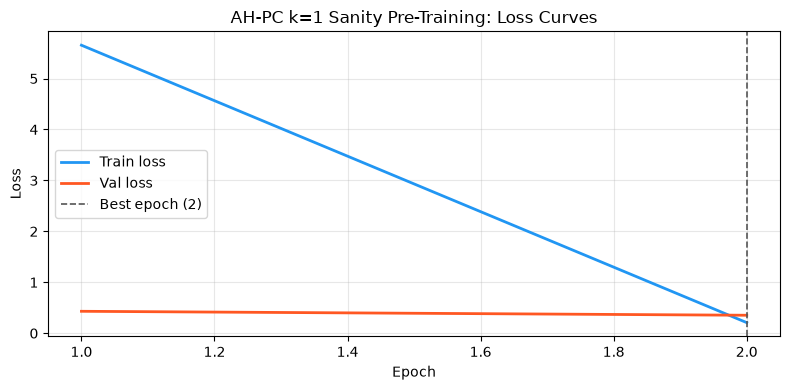

Saved -> /workspaces/AH-PC/src/notebooks/pretrain_k1_loss_curves.png


In [ ]:
PLOTS_DIR = "/workspaces/AH-PC/src/notebooks"
os.makedirs(PLOTS_DIR, exist_ok=True)

epochs_ran = list(range(1, len(train_losses) + 1))
best_epoch = int(np.argmin(val_losses)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train loss", linewidth=2, color="#2196F3")
ax.plot(epochs_ran, val_losses,   label="Val loss",   linewidth=2, color="#FF5722")
ax.axvline(best_epoch, color="#555", linestyle="--", linewidth=1.2,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("AH-PC k=1 Sanity Pre-Training: Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

loss_fig_path = os.path.join(PLOTS_DIR, "pretrain_k1_loss_curves.png")
plt.savefig(loss_fig_path, dpi=150)
plt.show()
print(f"Saved -> {loss_fig_path}")

---
## Summary

| Step | Status |
|------|--------|
| Model re-defined: k=1 only, no Horizon Attention Module | depends on run |
| SingleHorizonEEGDataset built (subject-level split) | depends on run |
| Loss function: plain k=1 MSE (no alpha weighting) | depends on run |
| Training loop: AdamW + cosine warmup + early stopping | depends on run |
| Best checkpoint saved to `src/models/ahpc_k1_pretrained_best.pt` | depends on run |
| Loss curves plotted | depends on run |

**Next step:** Notebook `04c_finetune_k1_raw.ipynb` — load this k=1 checkpoint, add a
classification head, and fine-tune with the same subject-dependent 3-fold CV protocol
as `04_finetune.ipynb`, to see whether single-horizon raw-feature-space pre-training
alone gets close to the PC-SSL baseline (83.02% ± 13.12%).